# Hardware-Efficient Neural Decoding of Surface Codes via Quantization-Aware Training

## Project Overview
This notebook implements Quantization-Aware Training (QAT) of neural network decoders 
for surface code quantum error correction (QEC). The question that we're trying to answer is how aggressively 
can we compress a learned QEC decoder before accuracy degrades?

## 1. Library Setup

Special installation required, this notebook uses QKeras 0.9 which requires TF 2.15 specifically:
```
pip install tensorflow-macos==2.15.0 keras==2.15.0 qkeras stim pymatching
```


In [3]:
import os
import csv
import time
import tempfile
from datetime import datetime

import numpy as np # array operations

import pandas as pd # results loading and analysi
import matplotlib.pyplot as plt # plotting
import matplotlib

# TensorFlow / Keras
# Must use tensorflow-macos==2.15.0 + keras==2.15.0 on Apple Silicon..
import tensorflow as tf
import keras

# QKeras — quantization-aware training layers
# QDense: quantized fully-connected layer
# QActivation: quantized activation (used between QDense layers)
# quantized_bits(b, i): b = total bits, i = integer bits, e.g. quantized_bits(4, 1) = 4-bit fixed-point with 1 integer bit
from qkeras import QDense, QActivation, quantized_bits

print(f'TF version:    {tf.__version__}')   # Expected: 2.15.0
print(f'Keras version: {keras.__version__}') # Expected: 2.15.0

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF version:    2.15.0
Keras version: 2.15.0


In [13]:
# --- Paths ---
# Datasets were generated in Phase 2 (Stim_generate_datasets.ipynb)
# Each file: data_d{d}_p{p:.3f}_r{ROUNDS}.npz
# Contains: det_evts (detector events), flips (logical observables)
DATA_DIR   = './datasets'
OUTPUT_DIR = './results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Syndrome rounds ---
# r=2 means 2 rounds of stabilizer measurements per sample.
# Syndrome length = (d^2 - 1) * r bits per sample.
ROUNDS = 2

# --- (d, p) configurations ---
# d = code distance (3, 5, 7) — larger d = more physical qubits, better protection
# p = physical error rate — probability of a gate/measurement error
# Surface code threshold is ~0.57% (Fowler et al. 2012),
# so p=0.001 and p=0.005 are below threshold, p=0.01 and p=0.05 above.
CONFIGS = [
    (3, 0.001), (3, 0.005), (3, 0.010), (3, 0.050),
    (5, 0.001), (5, 0.005), (5, 0.010), (5, 0.050),
    (7, 0.001), (7, 0.005), (7, 0.010), (7, 0.050),
]

# --- Quantization sweep grid ---
# (w_bits, a_bits): weight bit-width × activation bit-width
# 32 = full-precision float32 baseline (no quantization applied)
# 2, 4, 8 = aggressively quantized
# Total: 4 × 4 = 16 configurations per architecture
QUANT_CONFIGS = [
    (2, 2),  (2, 4),  (2, 8),  (2, 32),
    (4, 2),  (4, 4),  (4, 8),  (4, 32),
    (8, 2),  (8, 4),  (8, 8),  (8, 32),
    (32, 2), (32, 4), (32, 8), (32, 32),
]

# --- Training hyperparameters ---
# Same as Phase 4 (train_fullprecision.ipynb) for fair comparison.
# Early stopping monitors val_loss; if no improvement for PATIENCE epochs, stop.
# restore_best_weights=True ensures we keep the best checkpoint.
BATCH_SIZE    = 256
LEARNING_RATE = 1e-3
MAX_EPOCHS    = 100
PATIENCE      = 10

# --- Validation mode ---
# VALIDATE_ONLY = True:  run d=5, p=0.01 only (32 runs) to confirm pipeline works
# VALIDATE_ONLY = False: run all 12 (d,p) configs (384 runs) for full sweep
# Always validate first before committing to the full sweep.
VALIDATE_ONLY = True

sweep_configs = [(5, 0.010)] if VALIDATE_ONLY else CONFIGS

print(f'Sweep configs:         {sweep_configs}')
print(f'Quantization configs:  {len(QUANT_CONFIGS)}')
print(f'Architectures:         CNN-QDense, RCNN-QDense')
print(f'Total runs:            {len(sweep_configs) * len(QUANT_CONFIGS) * 2}')
print(f'Validate only:         {VALIDATE_ONLY}')

Sweep configs:         [(5, 0.01)]
Quantization configs:  16
Architectures:         CNN-QDense, RCNN-QDense
Total runs:            32
Validate only:         True


## Model Design

### Problem Formulation
Surface code decoding is a binary classification problem:
- **Input:** syndrome bits (detector events), a binary vector of length (d²-1) × rounds
- **Output:** logical observable flips — whether a logical error occurred

### Architecture Note
The CNN and RCNN decoders use quantized dense layers (QDense) for the classification 
head. Full QConv2D quantization was developed but encountered a TF/QKeras compatibility 
issue on Apple Silicon (TF ≥ 2.13); those experiments are reserved for future work. Results here focus on the QDense quantization.

In [14]:
# Cell 3 — Model Definitions

# Both architectures use keras.Sequential (not Functional API).
# QKeras 0.9 QDense layers are compatible with Sequential on TF 2.15.
#
# When w_bits=32, plain Keras Dense layers are used (no quantization), so (w=32, a=32) serves as the in-sweep full-precision baseline and should closely match Phase 4 results.
#
# QAT methodology: quantization constraints are active DURING training,not applied post-hoc. The network learns weights that work well under the specified bit-width constraints from the first epoch.

def build_qdense_cnn(input_shape, output_shape, w_bits, a_bits):
    """
    Quantized dense network (CNN-QDense).
    Architecture: Input → QDense(128) → QActivation → QDense(64) → QActivation → Dense(output)
    
    The name 'CNN-QDense' reflects that this replaces the CNN architecture
    from Phase 4 with a quantized dense equivalent. The QConv2D version
    (train_quantized.ipynb) is reserved for the Fermilab cluster.

    Args:
        input_shape:  tuple, e.g. (48,) for d=5 r=2
        output_shape: tuple, e.g. (1,) for single logical qubit
        w_bits:       int, weight bit-width (2/4/8/32)
        a_bits:       int, activation bit-width (2/4/8/32)

    Returns:
        Compiled-ready keras.Sequential model
    """
    if w_bits == 32:
        # Full-precision baseline — plain Dense layers, no QKeras
        model = keras.Sequential([
            keras.layers.Input(shape=input_shape),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dense(64,  activation='relu'),
            keras.layers.Dense(output_shape[0], activation='sigmoid'),
        ], name='CNN_QDense_fp32')
    else:
        # Quantized path
        # quantized_bits(w_bits, 1): fixed-point with 1 integer bit and (w_bits-1) fractional bits
        # quantized_relu(a_bits): ReLU clipped and quantized to a_bits
        # The final Dense output layer is NOT quantized — sigmoid output stays float
        w_q = quantized_bits(w_bits, 1)
        a_q = f'quantized_relu({a_bits})'
        model = keras.Sequential([
            keras.layers.Input(shape=input_shape),
            QDense(128, kernel_quantizer=w_q, bias_quantizer=w_q),
            QActivation(a_q),
            QDense(64,  kernel_quantizer=w_q, bias_quantizer=w_q),
            QActivation(a_q),
            keras.layers.Dense(output_shape[0], activation='sigmoid'),
        ], name=f'CNN_QDense_w{w_bits}a{a_bits}')
    return model


def build_qdense_rcnn(input_shape, output_shape, w_bits, a_bits):
    """
    Quantized recurrent network (RCNN-QDense).
    Architecture: Input → Reshape(1, n) → LSTM(32) → QDense(64) → QActivation → Dense(output)

    The LSTM captures temporal correlations across syndrome rounds.
    LSTM weights are kept full-precision (QKeras does not support QLSTM stably);
    only the dense classification head is quantized.

    Args:
        input_shape:  tuple, e.g. (48,) for d=5 r=2
        output_shape: tuple, e.g. (1,) for single logical qubit
        w_bits:       int, weight bit-width (2/4/8/32)
        a_bits:       int, activation bit-width (2/4/8/32)

    Returns:
        Compiled-ready keras.Sequential model
    """
    if w_bits == 32:
        # Full-precision baseline
        model = keras.Sequential([
            keras.layers.Input(shape=input_shape),
            keras.layers.Reshape((1, input_shape[0])),  # LSTM expects (batch, timesteps, features)
            keras.layers.LSTM(32, activation='relu'),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(output_shape[0], activation='sigmoid'),
        ], name='RCNN_QDense_fp32')
    else:
        # Quantized path — LSTM stays full-precision, dense head is quantized
        w_q = quantized_bits(w_bits, 1)
        a_q = f'quantized_relu({a_bits})'
        model = keras.Sequential([
            keras.layers.Input(shape=input_shape),
            keras.layers.Reshape((1, input_shape[0])),
            keras.layers.LSTM(32, activation='tanh'),   # tanh is standard LSTM activation
            QDense(64, kernel_quantizer=w_q, bias_quantizer=w_q),
            QActivation(a_q),
            keras.layers.Dense(output_shape[0], activation='sigmoid'),
        ], name=f'RCNN_QDense_w{w_bits}a{a_bits}')
    return model


def measure_model_size_kb(model):
    """
    Measure model size in kilobytes by saving to a temp .h5 file and checking disk size.
    This is a proxy for FPGA resource cost — smaller models = fewer LUTs and BRAMs needed.
    """
    with tempfile.NamedTemporaryFile(suffix='.h5', delete=False) as f:
        tmp = f.name
    model.save(tmp)
    kb = os.path.getsize(tmp) / 1024
    os.remove(tmp)
    return kb


def measure_inference_latency_ms(model, X_sample, n_repeats=10):
    """
    Measure wall-clock inference latency in milliseconds for a batch of 1000 samples.
    Runs n_repeats times and returns the mean.
    
    One warm-up call is made first to avoid measuring JIT compilation overhead.
    Latency is a direct measure of speedup — lower bit-width models should be faster
    on hardware that supports low-precision arithmetic (e.g. FPGA, edge accelerators).
    """
    batch = X_sample[:1000]
    model.predict(batch, verbose=0)  # warm-up pass
    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        model.predict(batch, verbose=0)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times))


# --- Sanity check: confirm input shapes for all distances ---
# syndrome length = (d^2 - 1) * rounds
# d=3: (9-1)*2 = 16 bits
# d=5: (25-1)*2 = 48 bits
# d=7: (49-1)*2 = 96 bits
print('Input shape sanity check:')
for d in [3, 5, 7]:
    n = (d**2 - 1) * ROUNDS
    print(f'  d={d}: input_shape=({n},)')
print('Model builders ready.')

Input shape sanity check:
  d=3: input_shape=(16,)
  d=5: input_shape=(48,)
  d=7: input_shape=(96,)
Model builders ready.


## Training Process

### Dataset
Syndrome data was generated using [Stim (Gidney 2021)](https://arxiv.org/abs/2103.02202) 
with a depolarizing noise model.
- 1,000,000 samples per (d, p) configuration
- 12 configurations: d ∈ {3,5,7} × p ∈ {0.001, 0.005, 0.01, 0.05}
- 80/10/10 train/val/test split (800k/100k/100k)

### Hyperparameter Choices
| Parameter | Value | Justification |
|-----------|-------|---------------|
| Batch size | 256 | Standard for tabular data; balances gradient noise and speed |
| Learning rate | 1e-3 | Adam default; works well for QAT |
| Max epochs | 100 | Ceiling only; early stopping fires first |
| Early stopping patience | 10 | Prevents overfitting; restores best checkpoint |

### Quantization-Aware Training (QAT)
QAT trains with quantization constraints active from epoch 1, the network learns
weights that work well under the specified bit-width. This allows the network to learn weight distributions that are robust to 
low-precision representation, typically resulting in significantly better 
accuracy at aggressive bit-widths.

### Sweep Design
16 (w,a) configurations × 2 architectures × 1 anchor config (d=5, p=0.01) = 32 runs
for validation. Full sweep: × 12 (d,p) configs = 384 runs total.

In [4]:
# Cell 4 — Training Sweep

# Outer loop: (d, p) configurations
# Middle loop: (w_bits, a_bits) quantization configurations
# Inner loop: architectures (CNN-QDense, RCNN-QDense)

# Results are written to CSV after EACH run so partial results are saved even if the sweep is interrupted.

# keras.backend.clear_session() is called after each model to free memory and prevent layer name collisions across runs.

csv_path   = f'{OUTPUT_DIR}/results_quantization_sweep_qdense.csv'
fieldnames = ['architecture', 'w_bits', 'a_bits', 'd', 'p',
              'p_L', 'model_size_kb', 'inference_latency_ms']

# Write CSV header (overwrites any previous file)
with open(csv_path, 'w', newline='') as f:
    csv.DictWriter(f, fieldnames=fieldnames).writeheader()

results    = []
total_runs = len(sweep_configs) * len(QUANT_CONFIGS) * 2
run_idx    = 0
t_start    = datetime.now()

for d, p in sweep_configs:

    # --- Load dataset ---
    # det_evts: detector events (syndrome bits), shape (N, syndrome_length)
    # flips:    logical observable flips, shape (N, n_observables)
    # Cast to float32 for TF compatibility
    data     = np.load(f'{DATA_DIR}/data_d{d}_p{p:.3f}_r{ROUNDS}.npz')
    det_evts = data['det_evts'].astype(np.float32)
    flips    = data['flips'].astype(np.float32)

    # --- 80/10/10 train/val/test split ---
    # Fixed split (no shuffle) — same as Phase 4 for consistency
    n_train, n_val = 800_000, 100_000
    X_train = det_evts[:n_train]
    y_train = flips[:n_train]
    X_val   = det_evts[n_train:n_train+n_val]
    y_val   = flips[n_train:n_train+n_val]
    X_test  = det_evts[n_train+n_val:]
    y_test  = flips[n_train+n_val:]

    input_shape  = X_train.shape[1:]
    output_shape = y_train.shape[1:]

    print(f'\n{"="*65}')
    print(f'd={d} p={p:.3f} | train={X_train.shape} val={X_val.shape} test={X_test.shape}')
    print(f'{"="*65}')

    for w_bits, a_bits in QUANT_CONFIGS:
        for arch_name, build_fn in [('CNN-QDense',  build_qdense_cnn),
                                    ('RCNN-QDense', build_qdense_rcnn)]:
            run_idx += 1
            print(f'\n  [{run_idx}/{total_runs}] {arch_name} w={w_bits} a={a_bits} | d={d} p={p:.3f}')

            try:
                # Build model
                model = build_fn(input_shape, output_shape, w_bits, a_bits)

                # Use legacy Adam optimizer — avoids M1/M2 Mac slowness warning with the default tf.keras.optimizers.Adam on Apple Silicon
                model.compile(
                    optimizer=keras.optimizers.legacy.Adam(learning_rate=LEARNING_RATE),
                    loss='binary_crossentropy',
                    metrics=['accuracy']
                )

                # Train with early stopping
                # EarlyStopping monitors val_loss; stops if no improvement for PATIENCE epochs restore_best_weights=True reverts to best checkpoint before returning
                model.fit(
                    X_train, y_train,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val, y_val),
                    epochs=MAX_EPOCHS,
                    callbacks=[keras.callbacks.EarlyStopping(
                        patience=PATIENCE,
                        restore_best_weights=True
                    )],
                    verbose=1
                )

                # --- Evaluate on test set ---
                # p_L = logical error rate = fraction of test samples where the decoder's prediction disagrees with the true logical flip.
                # .any(axis=1) counts a sample as wrong if ANY output bit is wrong (correct for multi-observable codes, safe for single-observable too)
                pred = (model.predict(X_test, verbose=0) > 0.5).astype(float)
                p_L  = float((pred != y_test).any(axis=1).sum()) / len(y_test)

                # Measure model size and inference latency
                kb  = measure_model_size_kb(model)
                lat = measure_inference_latency_ms(model, X_test)

                print(f'  -> p_L={p_L:.6f}  size={kb:.1f}KB  latency={lat:.1f}ms')

                # --- Save result ---
                row = {
                    'architecture':         arch_name,
                    'w_bits':               w_bits,
                    'a_bits':               a_bits,
                    'd':                    d,
                    'p':                    p,
                    'p_L':                  round(p_L, 8),
                    'model_size_kb':        round(kb, 2),
                    'inference_latency_ms': round(lat, 2),
                }
                results.append(row)

                # Append to CSV immediately so partial results survive interruptions
                with open(csv_path, 'a', newline='') as f:
                    csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

            except Exception as e:
                print(f'  ERROR: {e}')

            finally:
                # Free GPU/CPU memory and reset layer name counters between runs
                try:
                    del model
                except NameError:
                    pass
                keras.backend.clear_session()

print(f'\nDone: {len(results)}/{total_runs} runs succeeded.')
print(f'Elapsed: {datetime.now() - t_start}')
print(f'CSV saved to: {csv_path}')


d=5 p=0.010 | train=(800000, 48) val=(100000, 48) test=(100000, 48)

  [1/32] CNN-QDense w=2 a=2 | d=5 p=0.010
Epoch 1/100
3125/3125 [==============================] - 9s 3ms/step - loss: 0.2670 - accuracy: 0.8807 - val_loss: 0.2163 - val_accuracy: 0.9041
Epoch 2/100
3125/3125 [==============================] - 9s 3ms/step - loss: 0.1927 - accuracy: 0.9167 - val_loss: 0.1865 - val_accuracy: 0.9196
Epoch 3/100
3125/3125 [==============================] - 9s 3ms/step - loss: 0.1739 - accuracy: 0.9262 - val_loss: 0.1724 - val_accuracy: 0.9266
Epoch 4/100
3125/3125 [==============================] - 9s 3ms/step - loss: 0.1764 - accuracy: 0.9246 - val_loss: 0.1761 - val_accuracy: 0.9229
Epoch 5/100
3125/3125 [==============================] - 8s 2ms/step - loss: 0.1792 - accuracy: 0.9235 - val_loss: 0.1694 - val_accuracy: 0.9286
Epoch 6/100
3125/3125 [==============================] - 10s 3ms/step - loss: 0.1758 - accuracy: 0.9256 - val_loss: 0.1673 - val_accuracy: 0.9292
Epoch 7/100
3125/

/opt/anaconda3/envs/qkeras-tf215/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/opt/anaconda3/envs/qkeras-tf215/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


  -> p_L=0.069040  size=209.3KB  latency=57.2ms

  [2/32] RCNN-QDense w=2 a=2 | d=5 p=0.010
Epoch 1/100
3125/3125 [==============================] - 7s 2ms/step - loss: 0.2466 - accuracy: 0.8930 - val_loss: 0.1697 - val_accuracy: 0.9299
Epoch 2/100
3125/3125 [==============================] - 6s 2ms/step - loss: 0.1550 - accuracy: 0.9366 - val_loss: 0.1446 - val_accuracy: 0.9407
Epoch 3/100
3125/3125 [==============================] - 6s 2ms/step - loss: 0.1368 - accuracy: 0.9456 - val_loss: 0.1297 - val_accuracy: 0.9480
Epoch 4/100
3125/3125 [==============================] - 6s 2ms/step - loss: 0.1255 - accuracy: 0.9513 - val_loss: 0.1213 - val_accuracy: 0.9528
Epoch 5/100
3125/3125 [==============================] - 6s 2ms/step - loss: 0.1180 - accuracy: 0.9548 - val_loss: 0.1124 - val_accuracy: 0.9569
Epoch 6/100
3125/3125 [==============================] - 6s 2ms/step - loss: 0.1117 - accuracy: 0.9575 - val_loss: 0.1099 - val_accuracy: 0.9581
Epoch 7/100
3125/3125 [===============

## Evaluation Results

Results are loaded from CSV files generated by the full sweep.
The following analysis covers:
1. Architecture comparison: MWPM vs CNN vs RCNN
2. Quantization Pareto frontier
3. Quantization degradation by bit-width
4. Distance scaling behavior
5. Training stability map

In [4]:
# Load all result CSVs
df_mwpm  = pd.read_csv('./results/results_mwpm.csv')
df_fp    = pd.read_csv('./results/results_fullprecision.csv')
df_quant = pd.read_csv('./results/results_quantization_sweep_qdense.csv')

# Standardize column names across all CSVs
df_mwpm = df_mwpm.rename(columns={'distance':'d','noise':'p','decoder':'architecture'})
df_fp   = df_fp.rename(columns={'distance':'d','noise':'p','decoder':'architecture'})
df_fp['architecture'] = df_fp['architecture'].map({'CNN-32bit':'CNN','RCNN-32bit':'RCNN'})

# Drop the single duplicate run (RCNN w=32/a=4/d=7 appears twice) -> 384 rows
df_quant = df_quant.drop_duplicates(subset=['architecture','w_bits','a_bits','d','p'])

# Configs with quantized weights (w<32) and a full-precision activation quantizer (a=32)
# do NOT crash; they fail to learn and collapse to a trivial base-rate predictor.
df_quant['stable'] = ~((df_quant['w_bits'] < 32) & (df_quant['a_bits'] == 32))
df_stable   = df_quant[df_quant['stable']].copy()
df_unstable = df_quant[~df_quant['stable']].copy()

# Theoretical weight storage: bit-width applies ONLY to quantized layers.
# CNN-QDense: both QDense layers are quantized.
# RCNN-QDense: only the QDense head is quantized; LSTM backbone + output Dense stay 32-bit.
def param_split(arch, d, rounds=2):
    n = (d**2 - 1) * rounds
    if arch == 'CNN-QDense':
        q  = (n*128 + 128) + (128*64 + 64); fp = 64 + 1
    else:  # RCNN-QDense
        q  = 32*64 + 64; fp = 4*((n + 32)*32 + 32) + 64 + 1
    return q, fp

def theoretical_size_kb(row):
    q, fp = param_split(row['architecture'], row['d'])
    return (q*row['w_bits'] + fp*32) / 8 / 1024

df_stable['theoretical_size_kb'] = df_stable.apply(theoretical_size_kb, axis=1)

print(f'MWPM results:        {len(df_mwpm)} rows')
print(f'Full precision:      {len(df_fp)} rows')
print(f'Quantization total:  {len(df_quant)} rows')
print(f'  Stable:            {len(df_stable)} rows')
print(f'  Collapsed:         {len(df_unstable)} rows')

MWPM results:        12 rows
Full precision:      24 rows
Quantization total:  384 rows
  Stable:            312 rows
  Collapsed:         72 rows


### Figure 1 — Quantization Pareto Frontier

Each point represents one (w,a) quantization configuration. Pareto-optimal points (outlined) are configs where no other config is both smaller AND more accurate. Points are colored by weight bit-width.

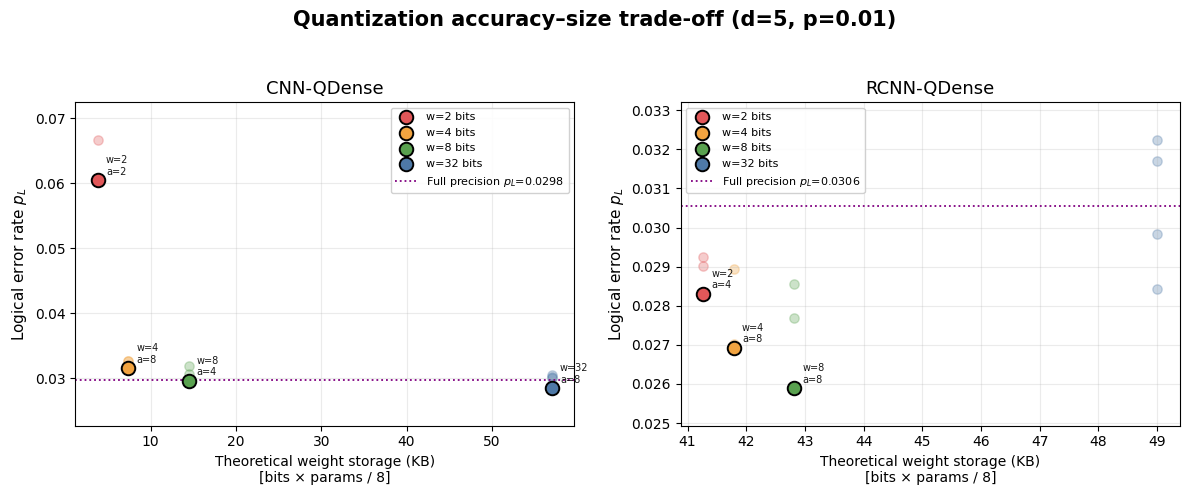

In [15]:
df = pd.read_csv("results/results_quantization_sweep_qdense.csv")

# --- copied verbatim from QATfinal_notebook.ipynb ---
def param_split(arch, d, rounds=2):
    n = (d**2 - 1) * rounds
    if arch == 'CNN-QDense':
        q  = (n*128 + 128) + (128*64 + 64); fp = 64 + 1
    else:  # RCNN-QDense
        q  = 32*64 + 64; fp = 4*((n + 32)*32 + 32) + 64 + 1
    return q, fp

def theoretical_size_kb(row):
    q, fp = param_split(row['architecture'], row['d'])
    return (q*row['w_bits'] + fp*32) / 8 / 1024
# ----------------------------------------------------

df["theoretical_size_kb"] = df.apply(theoretical_size_kb, axis=1)

D, P = 5, 0.01
sub = df[(df["d"] == D) & (np.isclose(df["p"], P))]

def pareto_mask(x, y):
    """True for non-dominated points (want low storage AND low p_L)."""
    xv, yv = np.asarray(x), np.asarray(y)
    m = np.ones(len(xv), bool)
    for i in range(len(xv)):
        dom = (xv <= xv[i]) & (yv <= yv[i]) & ((xv < xv[i]) | (yv < yv[i]))
        dom[i] = False
        if dom.any():
            m[i] = False
    return m

WBITS = [2, 4, 8, 32]
CMAP  = {2: "#E15759", 4: "#F1A340", 8: "#59A14F", 32: "#4E79A7"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, arch in zip(axes, ["CNN-QDense", "RCNN-QDense"]):
    a = sub[sub["architecture"] == arch]
    x, y = a["theoretical_size_kb"].values, a["p_L"].values
    pm, wv = pareto_mask(x, y), a["w_bits"].values
    for wb in WBITS:
        m = wv == wb
        ax.scatter(x[m & ~pm], y[m & ~pm], s=45, color=CMAP[wb], alpha=0.30)
        ax.scatter(x[m & pm],  y[m & pm],  s=95, color=CMAP[wb],
                   edgecolor="black", lw=1.4, label=f"w={wb} bits", zorder=5)
    fp = a[a["w_bits"] == 32]["p_L"].mean()
    ax.axhline(fp, ls=":", color="purple", lw=1.3, label=f"Full precision $p_L$={fp:.4f}")
    # zoom y-axis to this panel's stable points (exclude collapse cases)
    COLLAPSE_CUTOFF = 0.10          # anything above this is the w<32/a=32 collapse regime
    stable_y = y[y < COLLAPSE_CUTOFF]
    if len(stable_y):
        lo, hi = stable_y.min(), stable_y.max()
        pad = 0.15 * (hi - lo)      # 15% headroom each side
        ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(arch, fontsize=13)
    ax.set_xlabel("Theoretical weight storage (KB)\n[bits × params / 8]", fontsize=10)
    ax.set_ylabel("Logical error rate $p_L$", fontsize=11)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, framealpha=0.9)

# annotate Pareto-optimal points with their (w, a) config
    av = a["a_bits"].values
    for i in np.where(pm)[0]:
        ax.annotate(f"w={int(wv[i])}\na={int(av[i])}",
                    (x[i], y[i]), xytext=(6, 4),
                    textcoords="offset points", fontsize=7, alpha=0.9)

fig.suptitle(f"Quantization accuracy–size trade-off (d={D}, p={P})",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("plots/pareto_clean.png", dpi=160, bbox_inches="tight")
plt.show()

**Interpretation:** RCNN-QDense (w=8, a=8) is Pareto-optimal, reaching p_L = 0.0259 — just below the full-precision baseline (0.0298), consistent with quantization acting as a regularizer (QReg, arXiv:2206.12372). Two caveats: the 0.0039 margin is about the size of the run-to-run seed noise (see the w=32 spread in the stability/degradation figures), so it's suggestive not conclusive; and only the dense head is quantized while the LSTM stays float32, so the 4× saving is for the *head*, not the whole network — the RCNN's overall size barely changes. For CNN-QDense the opposite holds: nearly all its params are in the quantized dense layers, so 8-bit weights give a genuine ~4× weight-storage cut at full-precision accuracy. CNN p_L tracks full precision for w≥8, is marginally worse at w=4, and blows up at w=2; the spread among the w=32 points is pure seed variance, since every w=32 config uses the unquantized Dense path regardless of `a`.

### Figure 2 — Architecture Comparison

Compares MWPM, full-precision CNN-QDense, and RCNN-QDense across all physical error rates at d=5.

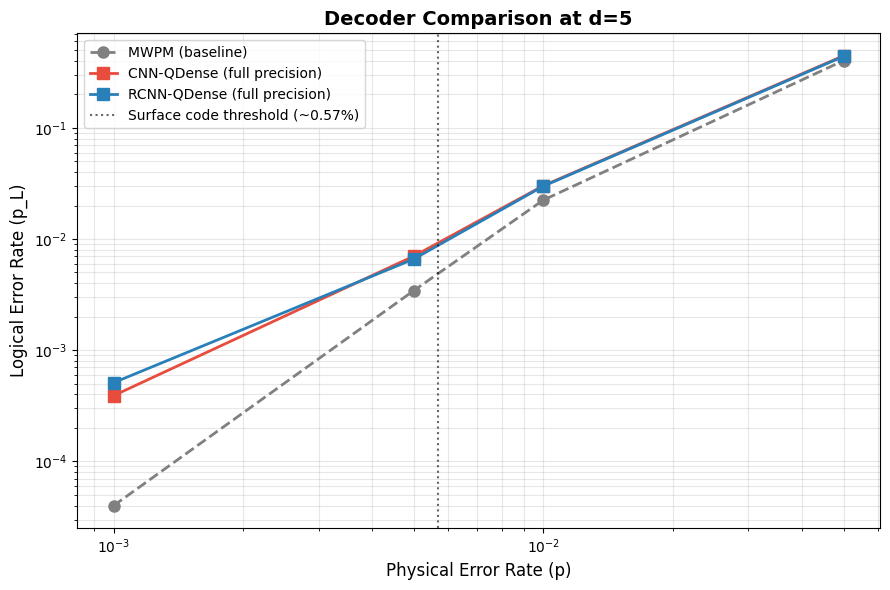

In [6]:
# Figure 2 — Architecture Comparison: MWPM vs CNN-QDense vs RCNN-QDense at d=5
# Uses the full-precision (w=32, a=32) baseline of the SAME QDense models that
# are quantized elsewhere in this notebook, so the comparison is internally
# consistent with the Pareto/degradation figures and the summary table.
D_VAL = 5
fig, ax = plt.subplots(figsize=(9, 6))

mwpm_sub = df_mwpm[df_mwpm['d'] == D_VAL].sort_values('p')
ax.loglog(mwpm_sub['p'], mwpm_sub['p_L'],
          'o--', color='gray', linewidth=2, markersize=8, label='MWPM (baseline)')

colors = {'CNN-QDense': '#e74c3c', 'RCNN-QDense': '#2980b9'}
for arch in ['CNN-QDense', 'RCNN-QDense']:
    fp_sub = df_stable[(df_stable['architecture'] == arch) &
                       (df_stable['d'] == D_VAL) &
                       (df_stable['w_bits'] == 32) &
                       (df_stable['a_bits'] == 32)].sort_values('p')
    ax.loglog(fp_sub['p'], fp_sub['p_L'],
              's-', color=colors[arch], linewidth=2, markersize=8,
              label=f'{arch} (full precision)')

ax.axvline(0.0057, color='black', linestyle=':', linewidth=1.5, alpha=0.6,
           label='Surface code threshold (~0.57%)')
ax.set_xlabel('Physical Error Rate (p)', fontsize=12)
ax.set_ylabel('Logical Error Rate (p_L)', fontsize=12)
ax.set_title(f'Decoder Comparison at d={D_VAL}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('./plots/architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** This compares MWPM against the full-precision (w=32, a=32) CNN-QDense and RCNN-QDense decoders. RCNN-QDense edges out CNN-QDense across error rates, and both trail MWPM, most at low p where MWPM's exploitation of code geometry helps most.

### Figure 3 — Quantization Degradation

Shows how p_L changes as weight bits decrease, for each activation bit-width. Reveals which dimension of quantization matters more.

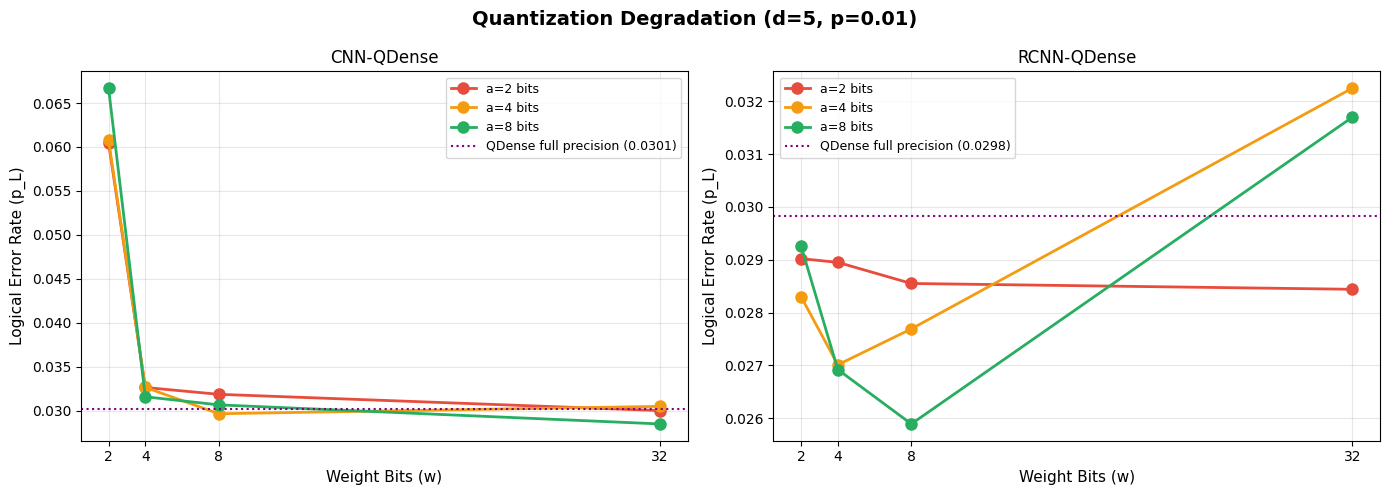

In [8]:
# Figure 3 — Quantization Degradation at d=5, p=0.01
ANCHOR_D = 5
ANCHOR_P = 0.010
A_BITS_VALS = [2, 4, 8]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Quantization Degradation (d={ANCHOR_D}, p={ANCHOR_P})', fontsize=14, fontweight='bold')

colors_a = {2: '#e74c3c', 4: '#f39c12', 8: '#27ae60'}
w_order  = [2, 4, 8, 32]

for ax, arch in zip(axes, ['CNN-QDense', 'RCNN-QDense']):
    subset = df_stable[
        (df_stable['d'] == ANCHOR_D) &
        (df_stable['p'] == ANCHOR_P) &
        (df_stable['architecture'] == arch)
    ]
    for a_bits in A_BITS_VALS:
        line_data = subset[subset['a_bits'] == a_bits].sort_values('w_bits')
        ax.plot(line_data['w_bits'], line_data['p_L'],
                'o-', color=colors_a[a_bits], linewidth=2, markersize=8, label=f'a={a_bits} bits')

    fp_val = df_stable[(df_stable['architecture'] == arch) &
                   (df_stable['d'] == ANCHOR_D) &
                   (df_stable['p'] == ANCHOR_P) &
                   (df_stable['w_bits'] == 32) &
                   (df_stable['a_bits'] == 32)]['p_L'].values
    if len(fp_val) > 0:
        ax.axhline(fp_val[0], color='purple', linestyle=':', linewidth=1.5,
                label=f'QDense full precision ({fp_val[0]:.4f})')

    ax.set_xlabel('Weight Bits (w)', fontsize=11)
    ax.set_ylabel('Logical Error Rate (p_L)', fontsize=11)
    ax.set_title(arch, fontsize=12)
    ax.set_xticks(w_order)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/quantization_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** For CNN, p_L jumps at w=2 (~0.06) and otherwise sits near full precision for w≥4 (w=4 is marginally above the FP line; w=8 is within seed noise). For RCNN, a shallow U-shape bottoms out near w=8, dipping below full precision (regularization) — but the w=32 end is the unquantized baseline retrained, so it also carries seed noise. Within a weight tier, activation bits move p_L by no more than the run-to-run noise, so weight bit-width dominates.

### Figure 4 — Distance Scaling

Shows p_L vs code distance d for selected quantization configs at fixed p=0.01.

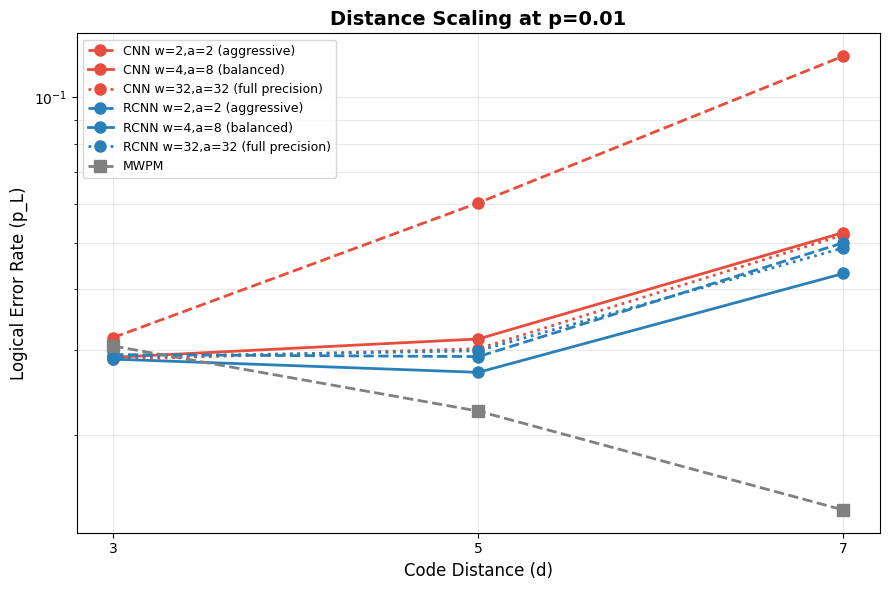

In [7]:
# Figure 4 — Distance Scaling at p=0.01
ANCHOR_P = 0.010
D_VALS   = [3, 5, 7]

configs_to_plot = [
    ('CNN-QDense',  2,  2, '#e74c3c', '--', 'CNN w=2,a=2 (aggressive)'),
    ('CNN-QDense',  4,  8, '#e74c3c', '-',  'CNN w=4,a=8 (balanced)'),
    ('CNN-QDense', 32, 32, '#e74c3c', ':',  'CNN w=32,a=32 (full precision)'),
    ('RCNN-QDense', 2,  2, '#2980b9', '--', 'RCNN w=2,a=2 (aggressive)'),
    ('RCNN-QDense', 4,  8, '#2980b9', '-',  'RCNN w=4,a=8 (balanced)'),
    ('RCNN-QDense',32, 32, '#2980b9', ':',  'RCNN w=32,a=32 (full precision)'),
]

fig, ax = plt.subplots(figsize=(9, 6))
for arch, w, a, color, ls, label in configs_to_plot:
    pts = []
    for d in D_VALS:
        row = df_stable[
            (df_stable['architecture'] == arch) &
            (df_stable['w_bits'] == w) &
            (df_stable['a_bits'] == a) &
            (df_stable['d'] == d) &
            (df_stable['p'] == ANCHOR_P)
        ]
        if len(row) > 0:
            pts.append((d, row['p_L'].values[0]))
    if pts:
        dx, dy = zip(*pts)
        ax.semilogy(dx, dy, 'o'+ls, color=color, linewidth=2, markersize=8, label=label)

mwpm_sub = df_mwpm[df_mwpm['p'] == ANCHOR_P].sort_values('d')
ax.semilogy(mwpm_sub['d'], mwpm_sub['p_L'], 's--', color='gray', linewidth=2, markersize=8, label='MWPM')

ax.set_xlabel('Code Distance (d)', fontsize=12)
ax.set_ylabel('Logical Error Rate (p_L)', fontsize=12)
ax.set_title(f'Distance Scaling at p={ANCHOR_P}', fontsize=14, fontweight='bold')
ax.set_xticks(D_VALS)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('./plots/distance_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** MWPM improves with code distance (p_L decreases), correctly exploiting the surface code's distance scaling property. QDense decoders degrade with distance, indicating the flat dense architecture cannot leverage the geometric structure of larger codes. The gap between quantization levels widens at d=7, meaning quantization has larger impact at higher distances.

### Figure 5 — Training Stability Map

Shows which (w,a) configurations learned successfully vs collapsed to a base-rate predictor (w<32 paired with a=32) at d=5, p=0.01.

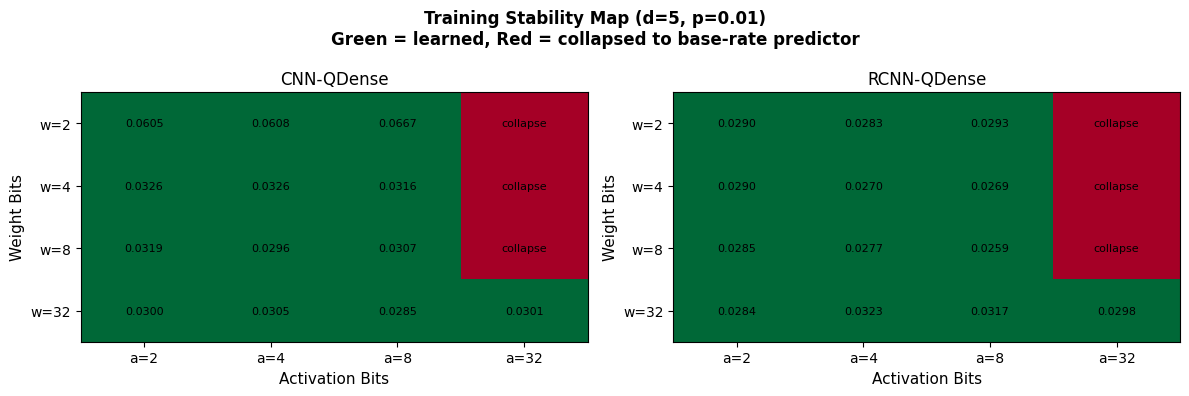

In [9]:
# Figure 5 — Training Stability Heatmap at d=5, p=0.01
ANCHOR_D = 5
ANCHOR_P = 0.010
W_VALS   = [2, 4, 8, 32]
A_VALS   = [2, 4, 8, 32]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Training Stability Map (d={ANCHOR_D}, p={ANCHOR_P})\nGreen = learned, Red = collapsed to base-rate predictor',
             fontsize=12, fontweight='bold')

for ax, arch in zip(axes, ['CNN-QDense', 'RCNN-QDense']):
    subset = df_quant[
        (df_quant['d'] == ANCHOR_D) &
        (df_quant['p'] == ANCHOR_P) &
        (df_quant['architecture'] == arch)
    ]
    matrix = np.zeros((len(W_VALS), len(A_VALS)))
    for i, w in enumerate(W_VALS):
        for j, a in enumerate(A_VALS):
            row = subset[(subset['w_bits'] == w) & (subset['a_bits'] == a)]
            if len(row) > 0:
                matrix[i, j] = 1.0 if row['stable'].values[0] else 0.0

    ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

    for i, w in enumerate(W_VALS):
        for j, a in enumerate(A_VALS):
            row = subset[(subset['w_bits'] == w) & (subset['a_bits'] == a)]
            if len(row) > 0:
                val = row['p_L'].values[0]
                text = f'{val:.4f}' if row['stable'].values[0] else 'collapse'
                ax.text(j, i, text, ha='center', va='center', fontsize=8, color='black')

    ax.set_xticks(range(len(A_VALS)))
    ax.set_yticks(range(len(W_VALS)))
    ax.set_xticklabels([f'a={a}' for a in A_VALS])
    ax.set_yticklabels([f'w={w}' for w in W_VALS])
    ax.set_xlabel('Activation Bits', fontsize=11)
    ax.set_ylabel('Weight Bits', fontsize=11)
    ax.set_title(arch, fontsize=12)

plt.tight_layout()
plt.savefig('./plots/stability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** Configs pairing quantized weights (w<32) with a full-precision activation quantizer (a=32) fail to learn. Each collapses to a trivial constant-output predictor whose p_L equals the dataset's logical-flip base rate (e.g. 0.200 at d=5,p=0.01; 0.014 at d=3,p=0.001), identical across all such configs for a given (d,p). 

### Summary Table

Key results at configuration d=5, p=0.01.

In [10]:
# Summary Statistics Table (matches Table 1 in the report)
AD, AP = 5, 0.010
MACS = {'CNN-QDense': 14400, 'RCNN-QDense': 12352}
QMAC = {'CNN-QDense': (14336, 64), 'RCNN-QDense': (2048, 10304)}  # (quantizable, full-precision) MACs

def _row(name, w, a, pl, sz, macs, eff):
    print(f'{name:<30}{w:>4}{a:>4}{pl:>10}{sz:>10}{macs:>9}{eff:>11}')

print(f'\n=== Summary Table: d={AD}, p={AP} ===')
_row('Decoder','w','a','p_L','Size(KB)','MACs','EffMACs')
print('-'*78)
mw = df_mwpm[(df_mwpm.d==AD)&(df_mwpm.p==AP)]['p_L'].iloc[0]
_row('MWPM (PyMatching)','—','—',f'{mw:.5f}','—','—','—')
print('-'*78)
for arch in ['CNN-QDense','RCNN-QDense']:
    s = df_stable[(df_stable.architecture==arch)&(df_stable.d==AD)&(df_stable.p==AP)]
    fp = s[(s.w_bits==32)&(s.a_bits==32)].iloc[0]
    qm, fpm = QMAC[arch]
    _row(arch+' (full precision)',32,32,f'{fp.p_L:.5f}',f'{fp.theoretical_size_kb:.1f}',f'{MACS[arch]:,}',f'{MACS[arch]:,}')
    best = s[s.w_bits<32].loc[s[s.w_bits<32].p_L.idxmin()]
    eff = int(round(qm*best.w_bits/32 + fpm))
    lab = '(8-bit weights)' if arch=='CNN-QDense' else '(8-bit head)'
    _row(arch+' '+lab,int(best.w_bits),int(best.a_bits),f'{best.p_L:.5f}',f'{best.theoretical_size_kb:.1f}',f'{MACS[arch]:,}',f'{eff:,}')
print('-'*78)
print('Sizes/MACs are analytic, applying bit-width only to quantized layers')
print('(RCNN LSTM + output stay 32-bit). CPU latency omitted: QKeras emulates')
print('low-precision in float32, so wall-clock time does not reflect speedup.')


=== Summary Table: d=5, p=0.01 ===
Decoder                          w   a       p_L  Size(KB)     MACs    EffMACs
------------------------------------------------------------------------------
MWPM (PyMatching)                —   —   0.02237         —        —          —
------------------------------------------------------------------------------
CNN-QDense (full precision)     32  32   0.03014      57.0   14,400     14,400
CNN-QDense (8-bit weights)       8   4   0.02964      14.4   14,400      3,648
RCNN-QDense (full precision)    32  32   0.02983      49.0   12,352     12,352
RCNN-QDense (8-bit head)         8   8   0.02589      42.8   12,352     10,816
------------------------------------------------------------------------------
Sizes/MACs are analytic, applying bit-width only to quantized layers
(RCNN LSTM + output stay 32-bit). CPU latency omitted: QKeras emulates
low-precision in float32, so wall-clock time does not reflect speedup.


## Key Findings

1. **8-bit-weight CNN-QDense matches full precision** (within run-to-run noise) at a genuine ~4× weight-storage reduction, because nearly all CNN params live in the quantized dense layers.
2. **RCNN-QDense (8-bit head) dips just below full precision** (p_L=0.0259 vs 0.0298), consistent with quantization-as-regularization (QReg, arXiv:2206.12372) — but the margin ≈ the seed noise, and only the dense head is quantized (LSTM stays float32), so whole-model size barely shrinks.
3. **a=32 + quantized weights → trivial collapse:** every w<32, a=32 config converges to a base-rate predictor. Reduce weight and activation precision together.
4. **Weight bits dominate accuracy;** within a weight tier, activation bits move p_L by ≤ the run-to-run noise.
5. **QDense decoders don't scale with code distance** (unlike MWPM) — Should explore the QConv2D decoder next.

## Limitations
- Single seed per config; run-to-run p_L variation ≈ ±0.002–0.004 (from repeated FP runs), comparable to the RCNN gain.
- Only dense layers quantized; the RCNN LSTM backbone stays full precision.
- These 'CNN'/'RCNN' decoders contain no convolution, and the LSTM sees a single timestep — they don't use spatial/temporal structure.
- Sizes/MACs are analytic; CPU wall-clock latency is not representative of low-precision hardware. No FPGA synthesis.

## Future Work
- QConv2D quantization sweep; quantize the LSTM (QLSTM) as well.
- Multiple seeds + error bars to confirm the regularization effect.
- Add raw measurement outcomes to the inputs (Bausch-style) to close the gap to MWPM.
- Threshold analysis (pseudo-threshold p*); FPGA LUT/latency estimation via hls4ml.